In [1]:
!pip install -q segmentation-models-pytorch pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.9 MB/s eta 0:00:00


In [27]:
DATASET_PATH = '/content/unzipped'

In [39]:
import os
import cv2
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from PIL import Image


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [24]:
class CalculatorDataset(Dataset):
    def __init__(self, data_dir, transforms=None):
        self.data_dir = data_dir
        self.transforms = transforms


        ann_file = os.path.join(data_dir, '_annotations.coco.json')
        with open(ann_file, 'r') as f:
            self.coco = json.load(f)


        self.images = self.coco['images']
        self.annotations = self.coco['annotations']


        self.img_to_anns = {}
        for ann in self.annotations:
            img_id = ann['image_id']
            if img_id not in self.img_to_anns:
                self.img_to_anns[img_id] = []
            self.img_to_anns[img_id].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_id   = img_info['id']
        img_path = os.path.join(self.data_dir, img_info['file_name'])


        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w  = image.shape[:2]


        mask = np.zeros((h, w), dtype=np.uint8)
        if img_id in self.img_to_anns:
            for ann in self.img_to_anns[img_id]:

                for seg in ann['segmentation']:
                    pts = np.array(seg, dtype=np.int32).reshape(-1, 2)
                    cv2.fillPoly(mask, [pts], color=1)


        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented['image']
            mask  = augmented['mask']


        mask = mask.unsqueeze(0).float()
        return image, mask

In [25]:

IMAGE_SIZE = 512

train_transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussianBlur(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_test_transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [28]:
train_dataset = CalculatorDataset(
    os.path.join(DATASET_PATH, 'train'),
    transforms=train_transforms
)
val_dataset = CalculatorDataset(
    os.path.join(DATASET_PATH, 'valid'),
    transforms=val_test_transforms
)
test_dataset = CalculatorDataset(
    os.path.join(DATASET_PATH, 'test'),
    transforms=val_test_transforms
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} images")
print(f"Val:   {len(val_dataset)} images")
print(f"Test:  {len(test_dataset)} images")

Train: 79 images
Val:   21 images
Test:  11 images


In [29]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)
model = model.to(device)
print("Model loaded successfully")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded successfully
Parameters: 24,436,369


In [31]:

class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)


        pred_sigmoid = torch.sigmoid(pred)
        smooth = 1e-6
        intersection = (pred_sigmoid * target).sum(dim=(2, 3))
        dice_loss = 1 - (2. * intersection + smooth) / (
            pred_sigmoid.sum(dim=(2,3)) + target.sum(dim=(2,3)) + smooth)
        dice_loss = dice_loss.mean()

        return bce_loss + dice_loss

criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5)

def compute_iou(pred, target, threshold=0.5):
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_bin * target).sum(dim=(2, 3))
    union = pred_bin.sum(dim=(2,3)) + target.sum(dim=(2,3)) - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

In [33]:
EPOCHS = 50
best_val_loss = float('inf')


history = {
    'train_loss': [], 'val_loss': [],
    'train_iou':  [], 'val_iou':  []
}

for epoch in range(EPOCHS):

    model.train()
    train_loss, train_iou = 0.0, 0.0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_iou  += compute_iou(outputs, masks)

    train_loss /= len(train_loader)
    train_iou  /= len(train_loader)


    model.eval()
    val_loss, val_iou = 0.0, 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, masks).item()
            val_iou  += compute_iou(outputs, masks)

    val_loss /= len(val_loader)
    val_iou  /= len(val_loader)

    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/best_model.pth')
        print(f"  ✓ Best model saved")

    # Log
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_iou'].append(train_iou)
    history['val_iou'].append(val_iou)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f}  Train IoU: {train_iou:.4f} | "
          f"Val Loss: {val_loss:.4f}  Val IoU: {val_iou:.4f}")

print("\nTraining complete!")

  ✓ Best model saved
Epoch [01/50] Train Loss: 0.9668  Train IoU: 0.5325 | Val Loss: 0.9406  Val IoU: 0.5212
  ✓ Best model saved
Epoch [02/50] Train Loss: 0.8689  Train IoU: 0.5926 | Val Loss: 0.8318  Val IoU: 0.5798
  ✓ Best model saved
Epoch [03/50] Train Loss: 0.8027  Train IoU: 0.6184 | Val Loss: 0.7793  Val IoU: 0.6182
  ✓ Best model saved
Epoch [04/50] Train Loss: 0.7640  Train IoU: 0.6433 | Val Loss: 0.7659  Val IoU: 0.6520
  ✓ Best model saved
Epoch [05/50] Train Loss: 0.7426  Train IoU: 0.7064 | Val Loss: 0.7365  Val IoU: 0.7321
Epoch [06/50] Train Loss: 0.7248  Train IoU: 0.7915 | Val Loss: 0.7479  Val IoU: 0.7309
  ✓ Best model saved
Epoch [07/50] Train Loss: 0.6995  Train IoU: 0.8082 | Val Loss: 0.7005  Val IoU: 0.7443
  ✓ Best model saved
Epoch [08/50] Train Loss: 0.6607  Train IoU: 0.8467 | Val Loss: 0.6873  Val IoU: 0.7858
  ✓ Best model saved
Epoch [09/50] Train Loss: 0.6313  Train IoU: 0.8489 | Val Loss: 0.6571  Val IoU: 0.7766
Epoch [10/50] Train Loss: 0.6006  Train 

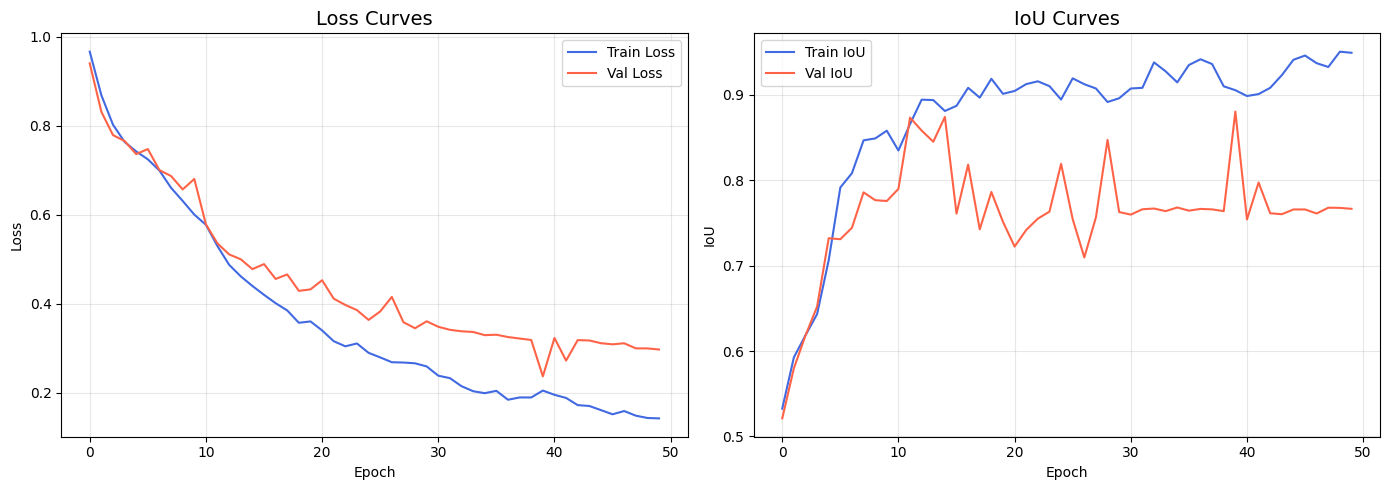

Curves saved to Drive


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(history['train_loss'], label='Train Loss', color='royalblue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Loss Curves', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].plot(history['train_iou'], label='Train IoU', color='royalblue')
axes[1].plot(history['val_iou'],   label='Val IoU',   color='tomato')
axes[1].set_title('IoU Curves', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('IoU')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()
print("Curves saved to Drive")

In [41]:
model.load_state_dict(torch.load(
    '/content/best_model.pth',
    map_location=device))
model.eval()

test_loss, test_iou = 0.0, 0.0
all_preds, all_masks = [], []

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        test_loss += criterion(outputs, masks).item()
        test_iou  += compute_iou(outputs, masks)
        all_preds.append(outputs.cpu())
        all_masks.append(masks.cpu())

test_loss /= len(test_loader)
test_iou  /= len(test_loader)


all_preds = torch.cat(all_preds)
all_masks = torch.cat(all_masks)
pred_bin  = (torch.sigmoid(all_preds) > 0.5).float()

TP = (pred_bin * all_masks).sum()
FP = (pred_bin * (1 - all_masks)).sum()
FN = ((1 - pred_bin) * all_masks).sum()

precision = (TP / (TP + FP + 1e-6)).item()
recall    = (TP / (TP + FN + 1e-6)).item()
f1        = (2 * precision * recall / (precision + recall + 1e-6))

print("----------------------------")
print("         TEST SET RESULTS")
print("----------------------------")
print(f"  Loss      : {test_loss:.4f}")
print(f"  IoU       : {test_iou:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")


----------------------------
         TEST SET RESULTS
----------------------------
  Loss      : 0.2651
  IoU       : 0.8728
  Precision : 0.9561
  Recall    : 0.8998
  F1 Score  : 0.9271


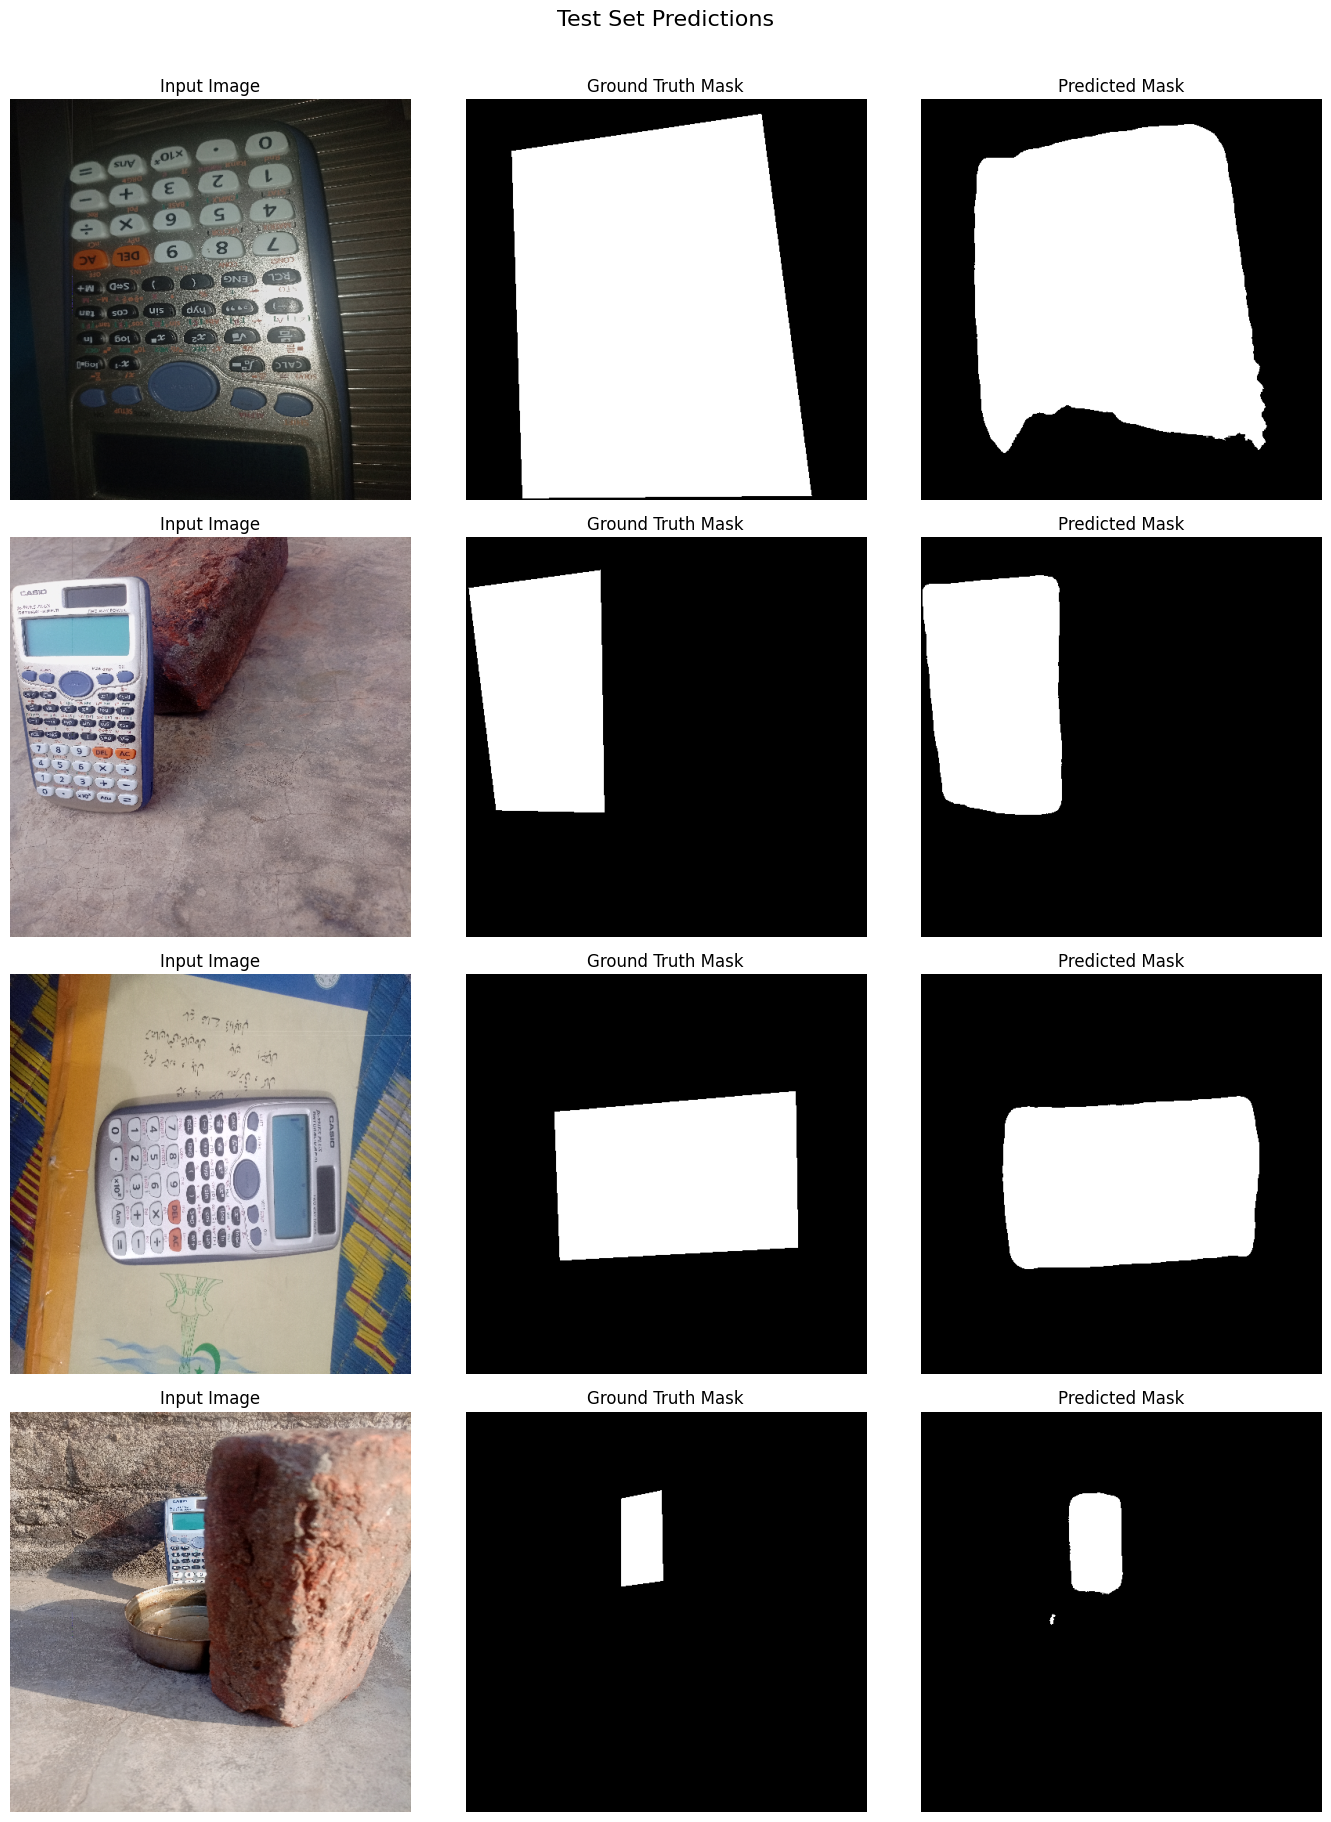

In [42]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

model.eval()
images_shown = 0
fig, axes = plt.subplots(4, 3, figsize=(14, 18))

with torch.no_grad():
    for images, masks in test_loader:
        for i in range(len(images)):
            if images_shown >= 4:
                break

            img   = images[i].to(device)
            mask  = masks[i]
            pred  = torch.sigmoid(model(img.unsqueeze(0))).squeeze().cpu()
            pred_bin = (pred > 0.5).float()

            ax_row = axes[images_shown]
            ax_row[0].imshow(denormalize(images[i]).permute(1,2,0))
            ax_row[0].set_title('Input Image')
            ax_row[0].axis('off')

            ax_row[1].imshow(mask.squeeze(), cmap='gray')
            ax_row[1].set_title('Ground Truth Mask')
            ax_row[1].axis('off')

            ax_row[2].imshow(pred_bin, cmap='gray')
            ax_row[2].set_title('Predicted Mask')
            ax_row[2].axis('off')

            images_shown += 1
        if images_shown >= 4:
            break

plt.suptitle('Test Set Predictions', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('/content/training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()